In [ ]:
import kagglehub
import os

# Download latest version
base_path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

# Adjust path to point to the actual data directory
path = os.path.join(base_path, 'Data')

print("Path to dataset files:", path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'stationery-dataset-1' dataset.
Path to dataset files: /kaggle/input/stationery-dataset-1/Data
Contents of base_path (/kaggle/input/stationery-dataset-1):
['Data']
Contents of path (/kaggle/input/stationery-dataset-1/Data):
['Test', 'Train']


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU is available:", gpu_available)
    print("TensorFlow is using GPU.")
else:
    print("No GPU devices found. TensorFlow will use CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is using GPU.


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of data for validation
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    path, # 'path' variable from the previous cell
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    path, # 'path' variable from the previous cell
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Get the number of classes from the generators
num_classes = train_generator.num_classes
print(f"Number of classes found: {num_classes}")

# Load the pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Add custom layers on top of DenseNet
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
EPOCHS = 10
print(f"Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

print("Model training complete.")

Found 1420 images belonging to 2 classes.
Found 354 images belonging to 2 classes.
Number of classes found: 2
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training for 10 epochs...
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7444 - loss: 0.5921 - val_accuracy: 0.7232 - val_loss: 0.6271
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 510ms/step - accuracy: 0.7599 - loss: 0.5405 - val_accuracy: 0.6977 - val_loss: 0.6319
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 523ms/step - accuracy: 0.7725 - loss: 0.5271 - val_accuracy: 0.7232 - val_loss: 0.6184
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 532ms/step - accuracy: 0.7648 - loss: 0.5227 - val_accuracy: 0.6949 - val_loss: 0.6437
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 530ms/step - accuracy: 0.7725 - loss: 0.5141 - val_accuracy: 0.6497 - val_loss: 0.6650
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 533ms/step - accuracy: 0.7789 - loss: 0.5091 - val_accuracy: 0.6949 - val_loss: 0.6568
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━

### Training Results Summary

In [ ]:
import pandas as pd

# Convert history to a DataFrame for easy viewing
history_df = pd.DataFrame(history.history)

# Display the last epoch's metrics
print("Last epoch's training metrics:")
print(history_df.iloc[-1][['loss', 'accuracy', 'val_loss', 'val_accuracy']])

# Get best validation accuracy
best_val_accuracy = history_df['val_accuracy'].max()
print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")

# Get best training accuracy
best_train_accuracy = history_df['accuracy'].max()
print(f"Best Training Accuracy: {best_train_accuracy:.4f}")

Last epoch's training metrics:
loss            0.495259
accuracy        0.775352
val_loss        0.667099
val_accuracy    0.697740
Name: 9, dtype: float64

Best Validation Accuracy: 0.7232
Best Training Accuracy: 0.7817


### Training History Plots

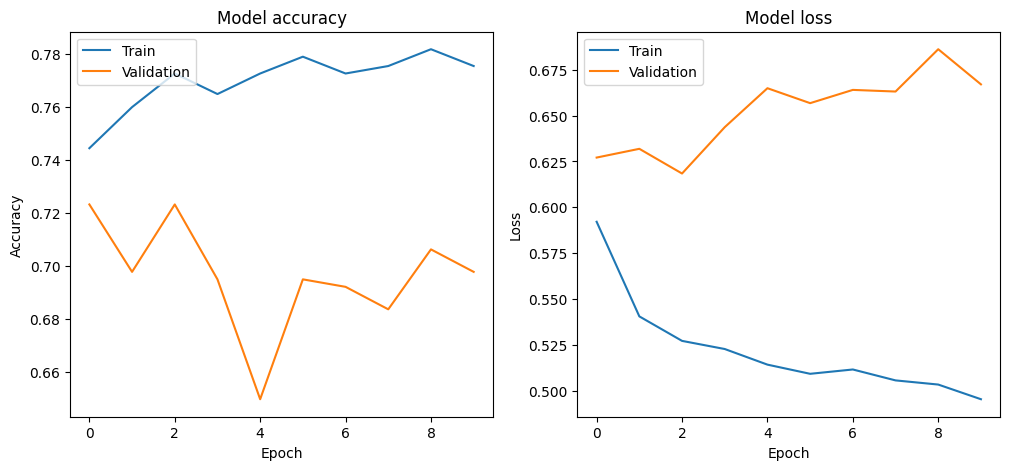

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()